# Melhor modelo da busca aleatória

In [ ]:
# Bibliotecas para manipulação de dados e visualização
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# TensorFlow e Keras para construção da rede neural
import tensorflow as tf
from keras.models import Sequential, load_model
from keras.layers import Input, Dense, BatchNormalization
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping, ModelCheckpoint

# Ferramentas para pré-processamento, divisão dos dados e avaliação
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

# Configuração dos gráficos
plt.rcParams.update({'font.size': 14})

## Semente aleatória

In [ ]:
# Define a semente para garantir a reprodutibilidade dos resultados
SEED = 42
np.random.seed(SEED)      # NumPy
tf.random.set_seed(SEED)  # TensorFlow

In [ ]:
def createWindows(df, windowSize):

    # Separa as variáveis de entrada e a variável alvo
    X = df.drop(columns=['valid_at', 'valore_originale', 'pm2p5_y']).values
    y = df['pm2p5_y'].values

    X_sep = []
    y_sep = []

    # Cria janelas deslizantes nos dados
    for i in range(len(X) - windowSize + 1):

        # Obtém e achata a janela de características
        janela_features = X[i : i + windowSize].flatten()
        X_sep.append(janela_features)

        # Define como alvo o último valor da janela
        alvo = y[i + windowSize - 1]
        y_sep.append(alvo)

    # Converte as listas em DataFrames
    X_final = pd.DataFrame(np.array(X_sep))
    y_final = pd.DataFrame(np.array(y_sep))

    return X_final, y_final

In [ ]:
# Parâmetros do modelo
totalFeatures = 6
windowSize    = 30
num_hidden    = 1024

## Dados e pré-processamento

In [ ]:
# Carregamento dos dados
ari_Mar_01 = pd.read_csv('Dados/ari-1727.csv')[::-1].reset_index(drop=True)
ari_Mar_02 = pd.read_csv('Dados/ari-1952.csv')[::-1].reset_index(drop=True)
ari_Mar_03 = pd.read_csv('Dados/ari-1953.csv')[::-1].reset_index(drop=True)
ari_Oct_01 = pd.read_csv('Dados/ari-1885.csv')[::-1].reset_index(drop=True)
ari_Oct_02 = pd.read_csv('Dados/ari-2049.csv')[::-1].reset_index(drop=True)
rf_01      = pd.read_csv('Dados/rf_1.csv')
rf_02      = pd.read_csv('Dados/rf_2.csv')

# Remoção de valores ausentes
ari_Mar_01.dropna(inplace=True)
ari_Mar_02.dropna(inplace=True)
ari_Mar_03.dropna(inplace=True)
ari_Oct_01.dropna(inplace=True)
ari_Oct_02.dropna(inplace=True)
rf_01.dropna(inplace=True)
rf_02.dropna(inplace=True)

# Conversão e ajuste das datas
ari_Mar_01['valid_at'] = pd.to_datetime(ari_Mar_01['valid_at'])
ari_Mar_02['valid_at'] = pd.to_datetime(ari_Mar_02['valid_at'])
ari_Mar_03['valid_at'] = pd.to_datetime(ari_Mar_03['valid_at'])
ari_Oct_01['valid_at'] = pd.to_datetime(ari_Oct_01['valid_at'])
ari_Oct_02['valid_at'] = pd.to_datetime(ari_Oct_02['valid_at'])
rf_01['valid_at']      = pd.to_datetime(rf_01['valid_at'])
rf_02['valid_at']      = pd.to_datetime(rf_02['valid_at'])

# Ajuste do fuso horário e arredondamento das datas
rf_01['valid_at'] = rf_01['valid_at'] - pd.Timedelta(hours=1)
rf_02['valid_at'] = rf_02['valid_at'] - pd.Timedelta(hours=1)

ari_Mar_01["valid_at"] = ari_Mar_01["valid_at"].dt.round("h")
ari_Mar_02["valid_at"] = ari_Mar_02["valid_at"].dt.round("h")
ari_Mar_03["valid_at"] = ari_Mar_03["valid_at"].dt.round("h")
ari_Oct_01["valid_at"] = ari_Oct_01["valid_at"].dt.round("h")
ari_Oct_02["valid_at"] = ari_Oct_02["valid_at"].dt.round("h")
rf_01["valid_at"]      = rf_01["valid_at"].dt.round("h")
rf_02["valid_at"]      = rf_02["valid_at"].dt.round("h")

# Combinação dos dados
Data_Mar_01 = pd.merge(ari_Mar_01, rf_01, on='valid_at', how='inner')
Data_Mar_02 = pd.merge(ari_Mar_02, rf_01, on='valid_at', how='inner')
Data_Mar_03 = pd.merge(ari_Mar_03, rf_01, on='valid_at', how='inner')
Data_Oct_01 = pd.merge(ari_Oct_01, rf_02, on='valid_at', how='inner')
Data_Oct_02 = pd.merge(ari_Oct_02, rf_02, on='valid_at', how='inner')

# Criação das janelas temporais
X_Mar_01, y_Mar_01 = createWindows(Data_Mar_01, windowSize)
X_Mar_02, y_Mar_02 = createWindows(Data_Mar_02, windowSize)
X_Mar_03, y_Mar_03 = createWindows(Data_Mar_03, windowSize)
X_Oct_01, y_Oct_01 = createWindows(Data_Oct_01, windowSize)
X_Oct_02, y_Oct_02 = createWindows(Data_Oct_02, windowSize)

# Montagem do conjunto de dados
X = pd.concat([X_Mar_01, X_Mar_02, X_Mar_03, X_Oct_01, X_Oct_02], ignore_index=True)
y = pd.concat([y_Mar_01, y_Mar_02, y_Mar_03, y_Oct_01, y_Oct_02], ignore_index=True)

# Divisão em treino, validação e teste
X_train, X_aux, y_train, y_aux = train_test_split(X, y, train_size=0.75, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_aux, y_aux, train_size=0.50, random_state=42)

# Ordenação dos índices
X_train.sort_index(inplace=True)
X_val.sort_index(inplace=True)
X_test.sort_index(inplace=True)
X_aux.sort_index(inplace=True)

y_train.sort_index(inplace=True)
y_val.sort_index(inplace=True)
y_test.sort_index(inplace=True)
y_aux.sort_index(inplace=True)

# Normalização dos dados
scaler_X = StandardScaler()
X_train = pd.DataFrame(scaler_X.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_val   = pd.DataFrame(scaler_X.transform(X_val), columns=X_val.columns, index=X_val.index)
X_test  = pd.DataFrame(scaler_X.transform(X_test), columns=X_test.columns, index=X_test.index)

scaler_y = StandardScaler()
y_train = pd.DataFrame(scaler_y.fit_transform(y_train.values.reshape(-1, 1)), columns=['target'], index=y_train.index)
y_val   = pd.DataFrame(scaler_y.transform(y_val.values.reshape(-1, 1)), columns=['target'], index=y_val.index)

## Modelo da melhor MLP

In [ ]:
# Arquitetura da rede neural
model = Sequential()

model.add(Input(shape=(totalFeatures * windowSize,)))
model.add(Dense(num_hidden, activation='relu'))
model.add(Dense(num_hidden, activation='relu'))
model.add(Dense(num_hidden, activation='relu'))
model.add(Dense(num_hidden, activation='relu'))
model.add(Dense(1))

# Exibe a arquitetura do modelo
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 1024)           │       185,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │         1,025 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,335,169 (12.72 MB)

 Trainable params: 3,335,169 (12.72 MB)

 Non-trainable params: 0 (0.00 B)

### Compilação do modelo de MLP

In [ ]:
# Configuração do treinamento
model.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=0.000352))

# Early stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

### Treinamento do modelo MLP

In [ ]:
# Treinamento do modelo
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=200,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/200
215/215 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - loss: 0.4982 - val_loss: 0.4153
Epoch 2/200
215/215 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - loss: 0.3961 - val_loss: 0.3698
Epoch 3/200
215/215 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 0.3509 - val_loss: 0.3474
Epoch 4/200
215/215 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 0.3117 - val_loss: 0.3320
Epoch 5/200
215/215 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 0.2872 - val_loss: 0.3217
Epoch 6/200
215/215 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 0.2736 - val_loss: 0.3060
Epoch 7/200
215/215 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 0.2574 - val_loss: 0.3053
Epoch 8/200
215/215 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.2383 - val_loss: 0.2900
Epoch 9/200
215/215 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 0.2309 - val_loss: 0.2809
Epoch 10/200
215/215 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.2192 - val_loss: 0.2720
Epoch 11/200
215/215 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 0.2154 - val_loss: 0.2894
Epoch 12/200
215/215 ━━━━━━━━━

## Teste da rede

In [ ]:
#Salvando o modelo treinado
model.save('Modelos/modelo_Melhorado.keras')

In [ ]:
#Prevendo com o modelo
model = load_model('Modelos/modelo_Melhorado.keras')

# 1. Faz as previsões
y_test_pred_scaled = model.predict(X_test)

# 2. Reverte a escala para os valores reais (ug/m3)
y_test_pred = scaler_y.inverse_transform(y_test_pred_scaled)

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


### Resultado do treinamento

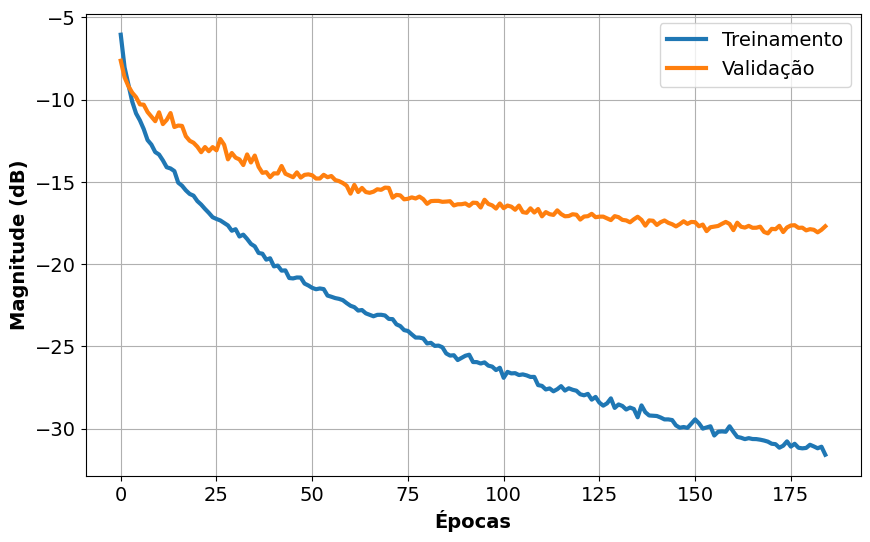

In [34]:
plt.figure(figsize=(10, 6))
plt.plot(20*np.log10(history.history['loss']), linewidth=3)
plt.plot(20*np.log10(history.history['val_loss']), linewidth=3)
plt.ylabel('Magnitude (dB)', fontweight='bold')
plt.xlabel('Épocas', fontweight='bold')
plt.legend(['Treinamento', 'Validação'], loc='upper right')
plt.grid()

### Resultado da estimação

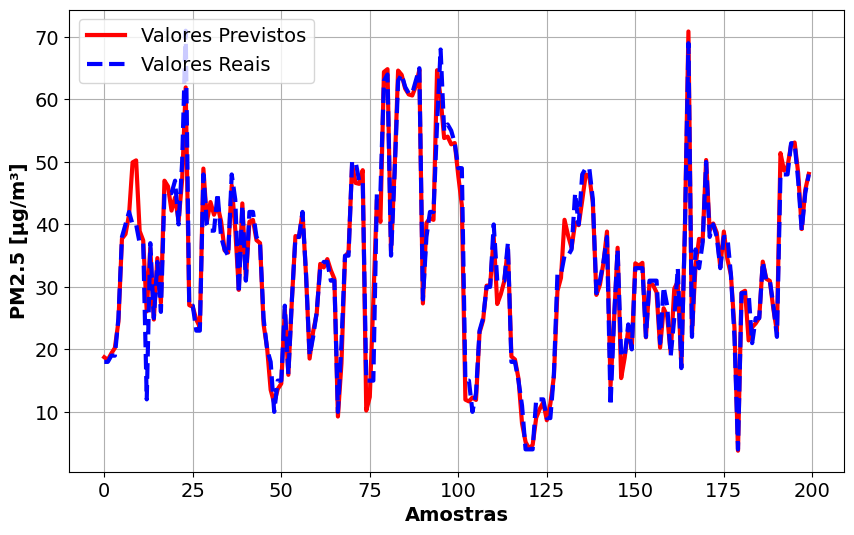

In [35]:
plt.figure(figsize=(10, 6))
plt.plot(y_test_pred[:200], 'r-', label='Valores Previstos', linewidth=3)
plt.plot(y_test.values[:200], 'b--', label='Valores Reais', linewidth=3)
plt.xlabel('Amostras', fontweight='bold')
plt.ylabel('PM2.5 [μg/m³]', fontweight='bold')
plt.grid()
plt.legend()

### Rersultado das métricas

In [ ]:
mae = mean_absolute_error(y_test.values, y_test_pred)
rmse = root_mean_squared_error(y_test.values, y_test_pred)
r2 = r2_score(y_test.values, y_test_pred)
print(f'MAE: {mae:.4f}')
print(f'RMSE: {rmse:.4f}')
print(f'R2: {r2:.4f}')

MAE: 2.0528
RMSE: 3.7522
R2: 0.9438


'0.9488'